从零实现 Softmax 回归 - MNIST 手写数字分类

数据集信息:
样本数量: 1797
特征维度: 64 (8×8 图像展平)
类别数量: 10 (数字 0-9)
标签范围: 0 - 9


C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_54224\945126572.py:32: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_54224\945126572.py:32: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from current font.
  plt.tight_layout()
C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_54224\945126572.py:32: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from current font.
  plt.tight_layout()
C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_54224\945126572.py:32: UserWarning: Glyph 20889 (\N{CJK UNIFIED IDEOGRAPH-5199}) missing from current font.
  plt.tight_layout()
C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_54224\945126572.py:32: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from current font.
  plt.tight_layout()
C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_54224\945126572.py:32: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from current f

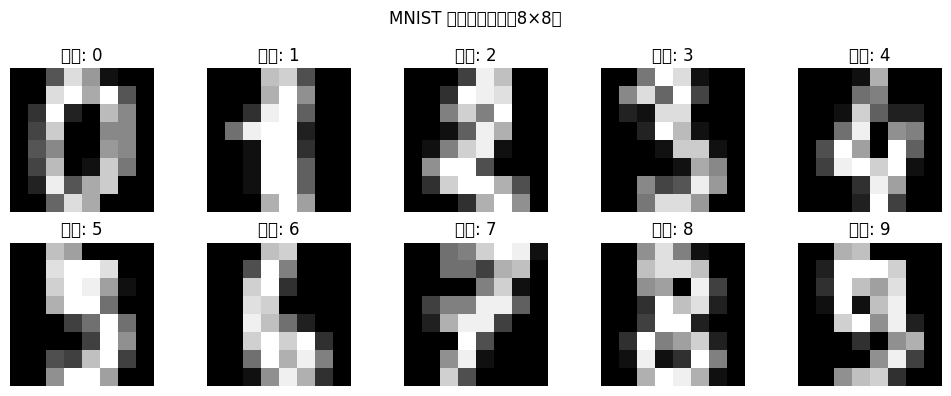

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 设置随机种子
np.random.seed(42)

print("="*60)
print("从零实现 Softmax 回归 - MNIST 手写数字分类")
print("="*60)

# 加载数据
digits = load_digits()
X = digits.data  # 特征 (1797, 64)
y = digits.target  # 标签 (1797,)

print(f"\n数据集信息:")
print(f"样本数量: {X.shape[0]}")
print(f"特征维度: {X.shape[1]} (8×8 图像展平)")
print(f"类别数量: {len(np.unique(y))} (数字 0-9)")
print(f"标签范围: {np.min(y)} - {np.max(y)}")

# 显示部分样本
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'数字: {y[i]}')
    ax.axis('off')
plt.suptitle('MNIST 手写数字样本（8×8）')
plt.tight_layout()
plt.show()

In [3]:
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n数据划分:")
print(f"训练集大小: {X_train.shape[0]}")
print(f"测试集大小: {X_test.shape[0]}")

# 标准化（提高训练稳定性）
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"\n特征标准化完成")
print(f"训练集均值: {X_train.mean():.3f}, 标准差: {X_train.std():.3f}")
print(f"测试集均值: {X_test.mean():.3f}, 标准差: {X_test.std():.3f}")

# One-hot 编码函数
def one_hot_encoding(y, num_classes=10):
    """将标签转换为 one-hot 编码"""
    n_samples = len(y)
    y_one_hot = np.zeros((n_samples, num_classes))
    y_one_hot[np.arange(n_samples), y] = 1
    return y_one_hot

# 转换标签
y_train_one_hot = one_hot_encoding(y_train)
y_test_one_hot = one_hot_encoding(y_test)

print(f"\nOne-hot 编码后:")
print(f"训练集标签形状: {y_train_one_hot.shape}")
print(f"第一个样本的 one-hot: {y_train_one_hot[0]}")
print(f"对应的数字: {y_train[0]}")


数据划分:
训练集大小: 1437
测试集大小: 360

特征标准化完成
训练集均值: 0.000, 标准差: 0.976
测试集均值: -0.004, 标准差: 1.103

One-hot 编码后:
训练集标签形状: (1437, 10)
第一个样本的 one-hot: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
对应的数字: 5


In [4]:
class SoftmaxRegression:
    """从零实现的 Softmax 回归分类器"""
    
    def __init__(self, input_dim, num_classes, learning_rate=0.1):
        """
        初始化参数
        input_dim: 输入特征维度 (64)
        num_classes: 类别数量 (10)
        learning_rate: 学习率
        """
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.learning_rate = learning_rate
        
        # 初始化权重和偏置（小随机数）
        self.W = np.random.randn(input_dim, num_classes) * 0.01
        self.b = np.zeros((1, num_classes))
        
    def softmax(self, z):
        """
        Softmax 函数
        将 logits 转换为概率分布
        """
        # 数值稳定性：减去最大值
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def forward(self, X):
        """
        前向传播
        X: (n_samples, input_dim)
        返回: 每个类别的概率 (n_samples, num_classes)
        """
        # 线性变换: z = X·W + b
        z = np.dot(X, self.W) + self.b
        # Softmax 激活
        return self.softmax(z)
    
    def cross_entropy_loss(self, y_pred, y_true):
        """
        交叉熵损失函数
        y_pred: 预测概率 (n_samples, num_classes)
        y_true: one-hot 标签 (n_samples, num_classes)
        返回: 平均损失
        """
        n_samples = y_pred.shape[0]
        # 避免 log(0)
        eps = 1e-8
        loss = -np.sum(y_true * np.log(y_pred + eps)) / n_samples
        return loss
    
    def compute_gradients(self, X, y_pred, y_true):
        """
        计算梯度
        X: 输入特征 (n_samples, input_dim)
        y_pred: 预测概率 (n_samples, num_classes)
        y_true: one-hot 标签 (n_samples, num_classes)
        """
        n_samples = X.shape[0]
        
        # 梯度计算
        # dL/dz = y_pred - y_true
        dz = y_pred - y_true
        
        # dL/dW = X^T · dz
        dW = np.dot(X.T, dz) / n_samples
        
        # dL/db = sum(dz) / n_samples
        db = np.sum(dz, axis=0, keepdims=True) / n_samples
        
        return dW, db
    
    def update_parameters(self, dW, db):
        """使用梯度下降更新参数"""
        self.W -= self.learning_rate * dW
        self.b -= self.learning_rate * db
    
    def train_batch(self, X_batch, y_batch):
        """训练一个批次"""
        # 前向传播
        y_pred = self.forward(X_batch)
        
        # 计算损失
        loss = self.cross_entropy_loss(y_pred, y_batch)
        
        # 计算梯度
        dW, db = self.compute_gradients(X_batch, y_pred, y_batch)
        
        # 更新参数
        self.update_parameters(dW, db)
        
        return loss
    
    def predict(self, X):
        """预测类别"""
        y_pred = self.forward(X)
        return np.argmax(y_pred, axis=1)
    
    def accuracy(self, X, y):
        """计算准确率"""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

# 创建模型
model = SoftmaxRegression(
    input_dim=X_train.shape[1], 
    num_classes=10, 
    learning_rate=0.1
)

print("Softmax 回归模型创建成功！")
print(f"输入维度: {model.input_dim}")
print(f"输出类别: {model.num_classes}")
print(f"学习率: {model.learning_rate}")
print(f"权重形状: {model.W.shape}")
print(f"偏置形状: {model.b.shape}")

Softmax 回归模型创建成功！
输入维度: 64
输出类别: 10
学习率: 0.1
权重形状: (64, 10)
偏置形状: (1, 10)


In [5]:
# 训练参数
batch_size = 32
epochs = 50
n_samples = X_train.shape[0]
n_batches = int(np.ceil(n_samples / batch_size))

# 记录训练历史
train_losses = []
train_accuracies = []
test_accuracies = []

print("="*60)
print("开始训练")
print("="*60)
print(f"批次大小: {batch_size}")
print(f"训练轮数: {epochs}")
print(f"每轮批次数: {n_batches}")
print("-"*60)

for epoch in range(epochs):
    # 打乱训练数据
    indices = np.random.permutation(n_samples)
    X_shuffled = X_train[indices]
    y_shuffled = y_train_one_hot[indices]
    
    epoch_loss = 0
    
    # 小批量训练
    for batch_idx in range(n_batches):
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, n_samples)
        
        X_batch = X_shuffled[start_idx:end_idx]
        y_batch = y_shuffled[start_idx:end_idx]
        
        loss = model.train_batch(X_batch, y_batch)
        epoch_loss += loss
    
    # 平均损失
    avg_loss = epoch_loss / n_batches
    
    # 计算准确率
    train_acc = model.accuracy(X_train, y_train)
    test_acc = model.accuracy(X_test, y_test)
    
    # 记录历史
    train_losses.append(avg_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    # 打印进度
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | "
              f"Loss: {avg_loss:.4f} | "
              f"Train Acc: {train_acc:.4f} | "
              f"Test Acc: {test_acc:.4f}")

print("-"*60)
print("训练完成！")

开始训练
批次大小: 32
训练轮数: 50
每轮批次数: 45
------------------------------------------------------------
Epoch   5/50 | Loss: 0.2008 | Train Acc: 0.9687 | Test Acc: 0.9444
Epoch  10/50 | Loss: 0.1340 | Train Acc: 0.9798 | Test Acc: 0.9500
Epoch  15/50 | Loss: 0.1060 | Train Acc: 0.9847 | Test Acc: 0.9556
Epoch  20/50 | Loss: 0.0894 | Train Acc: 0.9889 | Test Acc: 0.9639
Epoch  25/50 | Loss: 0.0780 | Train Acc: 0.9889 | Test Acc: 0.9639
Epoch  30/50 | Loss: 0.0698 | Train Acc: 0.9903 | Test Acc: 0.9639
Epoch  35/50 | Loss: 0.0634 | Train Acc: 0.9937 | Test Acc: 0.9639
Epoch  40/50 | Loss: 0.0582 | Train Acc: 0.9951 | Test Acc: 0.9639
Epoch  45/50 | Loss: 0.0540 | Train Acc: 0.9958 | Test Acc: 0.9667
Epoch  50/50 | Loss: 0.0505 | Train Acc: 0.9958 | Test Acc: 0.9667
------------------------------------------------------------
训练完成！


C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_54224\2280810138.py:20: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from current font.
  plt.tight_layout()
C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_54224\2280810138.py:20: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from current font.
  plt.tight_layout()
C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_54224\2280810138.py:20: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from current font.
  plt.tight_layout()
C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_54224\2280810138.py:20: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from current font.
  plt.tight_layout()
C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_54224\2280810138.py:20: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from current font.
  plt.tight_layout()
C:\Users\邓宇阳\AppData\Local\Temp\ipykernel_54224\2280810138.py:20: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from cur

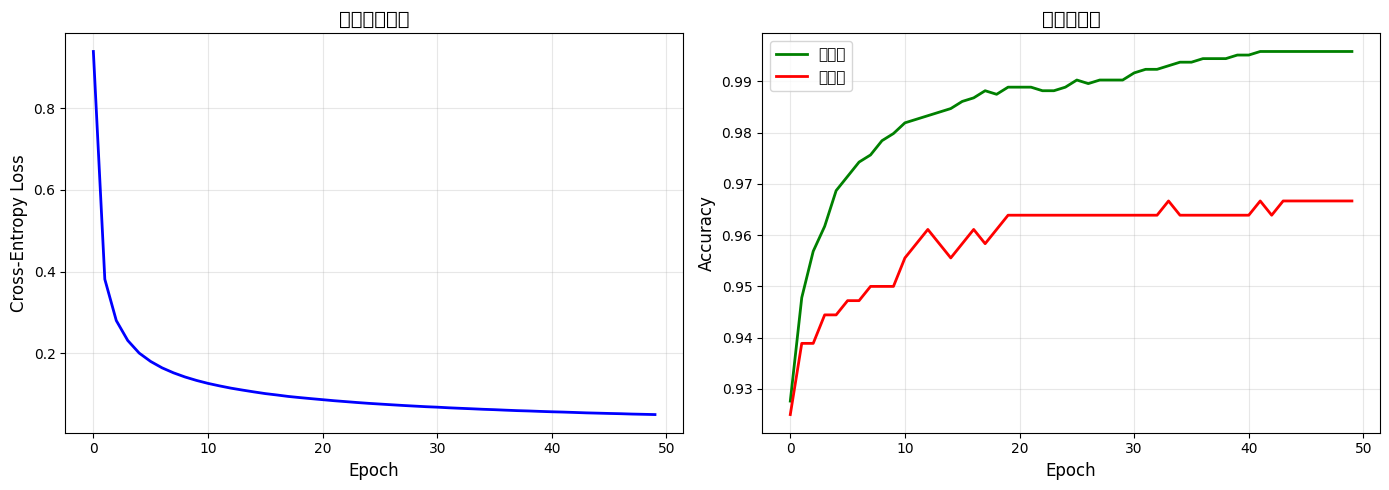


最终结果
训练集准确率: 0.9958 (99.58%)
测试集准确率: 0.9667 (96.67%)


In [6]:
# 绘制训练曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 损失曲线
axes[0].plot(train_losses, 'b-', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Cross-Entropy Loss', fontsize=12)
axes[0].set_title('训练损失曲线', fontsize=14)
axes[0].grid(True, alpha=0.3)

# 准确率曲线
axes[1].plot(train_accuracies, 'g-', linewidth=2, label='训练集')
axes[1].plot(test_accuracies, 'r-', linewidth=2, label='测试集')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('准确率曲线', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 最终结果
final_train_acc = train_accuracies[-1]
final_test_acc = test_accuracies[-1]

print("\n" + "="*60)
print("最终结果")
print("="*60)
print(f"训练集准确率: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"测试集准确率: {final_test_acc:.4f} ({final_test_acc*100:.2f}%)")